In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [2]:
# Representación visual del grid de Frozen Lake
frozen_lake_grid = np.array([
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
])

print(frozen_lake_grid)

[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]


Número de estados  (observation_space.n): 16
Número de acciones (action_space.n)      : 4

Descripción de los espacios:
  observation_space : Discrete(16)
  action_space      : Discrete(4)

Acciones posibles: 0=Izquierda, 1=Abajo, 2=Derecha, 3=Arriba


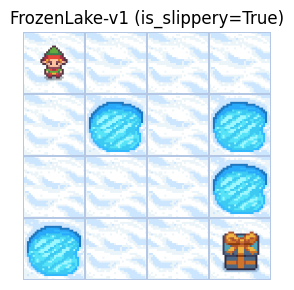

In [3]:
# ─── Task 2.1 ──────────────────────────────────────────────────────────────
# Inicializar el entorno FrozenLake-v1 con hielo resbaladizo (estocástico)
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
env.reset()

# Explorar el espacio de estados y acciones
n_states  = env.observation_space.n
n_actions = env.action_space.n

print(f"Número de estados  (observation_space.n): {n_states}")
print(f"Número de acciones (action_space.n)      : {n_actions}")
print()
print("Descripción de los espacios:")
print(f"  observation_space : {env.observation_space}")
print(f"  action_space      : {env.action_space}")
print()
print("Acciones posibles: 0=Izquierda, 1=Abajo, 2=Derecha, 3=Arriba")

# Renderizar el estado inicial
frame = env.render()
plt.figure(figsize=(3, 3))
plt.imshow(frame)
plt.axis("off")
plt.title("FrozenLake-v1 (is_slippery=True)")
plt.tight_layout()
plt.show()

env.close()

In [4]:
# ─── Task 2.1 – Modelado del MDP ────────────────────────────────────────────
# Estados S : 0-15 (izquierda→derecha, arriba→abajo)
# Acciones A: 0=N, 1=E, 2=S, 3=O
n_states  = 16
n_actions = 4
actions   = ['N', 'E', 'S', 'O']

T = np.zeros((n_states, n_actions, n_states))  # Transición T(s, a, s')
R = np.zeros((n_states, n_actions, n_states))  # Recompensa R(s, a, s')

def get_coord(state):
    """Convierte estado (0–15) a (fila, columna)."""
    return state // 4, state % 4

def get_state(row, col):
    """Convierte (fila, columna) a estado (0–15)."""
    return row * 4 + col

def try_move(row, col, direction_id):
    """Calcula nueva posición respetando límites del grid."""
    if   direction_id == 0: row = max(0, row - 1)    # Norte
    elif direction_id == 1: col = min(3, col + 1)    # Este
    elif direction_id == 2: row = min(3, row + 1)    # Sur
    elif direction_id == 3: col = max(0, col - 1)    # Oeste
    return row, col

# Acción → [dirección deseada, desvío 1, desvío 2]
stochastic_directions = {
    0: [0, 1, 3],  # Norte  → puede resbalar a Este u Oeste
    1: [1, 0, 2],  # Este   → puede resbalar a Norte o Sur
    2: [2, 1, 3],  # Sur    → puede resbalar a Este u Oeste
    3: [3, 0, 2],  # Oeste  → puede resbalar a Norte o Sur
}

print("Funciones auxiliares y diccionario de direcciones definidos.")

Funciones auxiliares y diccionario de direcciones definidos.


In [5]:
# ─── Construcción de las matrices T y R ─────────────────────────────────────
for s in range(n_states):
    row, col   = get_coord(s)
    cell_type  = frozen_lake_grid[row, col]

    # Estados terminales: H (agujero) o G (meta)
    # El agente queda atrapado; probabilidad 1 de quedarse, recompensa 0.
    if cell_type in ('H', 'G'):
        for a in range(n_actions):
            T[s, a, s] = 1.0
            R[s, a, s] = 0.0
        continue

    # Estados normales: S o F
    for a in range(n_actions):
        for move_dir in stochastic_directions[a]:
            next_row, next_col = try_move(row, col, move_dir)
            s_prime            = get_state(next_row, next_col)
            next_cell_type     = frozen_lake_grid[next_row, next_col]

            # Cada una de las 3 direcciones ocurre con prob. 1/3.
            # Se usa += para acumular cuando dos direcciones convergen al mismo s'.
            T[s, a, s_prime] += 1 / 3

            # Recompensa = 1 sólo si el estado destino es la meta (G).
            if next_cell_type == 'G':
                R[s, a, s_prime] = 1.0

print("¡Matrices T y R construidas con éxito!")
print(f"  T.shape = {T.shape}  (estados × acciones × estados)")
print(f"  R.shape = {R.shape}  (estados × acciones × estados)")

¡Matrices T y R construidas con éxito!
  T.shape = (16, 4, 16)  (estados × acciones × estados)
  R.shape = (16, 4, 16)  (estados × acciones × estados)


# Task 2.2 Entrenamiento de un agente con Q-Learning

In [6]:

# 1. Inicializar entorno y tabla Q
env_ql = gym.make("FrozenLake-v1", is_slippery=True)
n_states  = env_ql.observation_space.n   # 16
n_actions = env_ql.action_space.n        # 4

Q = np.zeros((n_states, n_actions))

# 2a. Hiperparametros
alpha        = 0.8      # Learning rate 
gamma        = 0.95     # Factor de descuento
epsilon      = 1.0      # Exploración inicial
epsilon_min  = 0.01     # Mínimo de epsilon
epsilon_decay= 0.001    # Decay por episodio
n_episodes   = 10_000   # Número de episodios

# Para seguimiento del entrenamiento
rewards_per_episode = []

# 2b. Bucle de entrenamiento
for episode in range(n_episodes):
    state, _ = env_ql.reset()
    total_reward = 0
    done = False

    while not done:
        # 2b-i-a. Epsilon-Greedy: exploración vs explotación
        if np.random.uniform(0, 1) < epsilon:
            action = env_ql.action_space.sample()          # Exploración aleatoria
        else:
            action = np.argmax(Q[state, :])                # Explotación de la tabla Q

        # 2b-i-b. Ejecutar acción
        new_state, reward, terminated, truncated, _ = env_ql.step(action)
        done = terminated or truncated

        # 2b-i-c. Actualizar Q(s, a) ← Q(s,a) + α[R + γ·max Q(s',a') − Q(s,a)]
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[new_state, :]) - Q[state, action]
        )

        # 2b-i-d. Actualizar estado actual
        state = new_state
        total_reward += reward

    rewards_per_episode.append(total_reward)

    # Decay de epsilon
    epsilon = max(epsilon_min, epsilon - epsilon_decay)

env_ql.close()

print("¡Entrenamiento Q-Learning completado!")
print(f"  Episodios entrenados : {n_episodes}")
print(f"  Epsilon final        : {epsilon:.4f}")
print(f"  Tasa de éxito (últimos 1000 ep): {np.mean(rewards_per_episode[-1000:]):.2%}")


¡Entrenamiento Q-Learning completado!
  Episodios entrenados : 10000
  Epsilon final        : 0.0100
  Tasa de éxito (últimos 1000 ep): 53.60%


# Task 2.3 – Evaluación y visualización de la Tabla Q entrenada

Episodios de prueba : 10
Victorias           : 4
Win Rate            : 40%


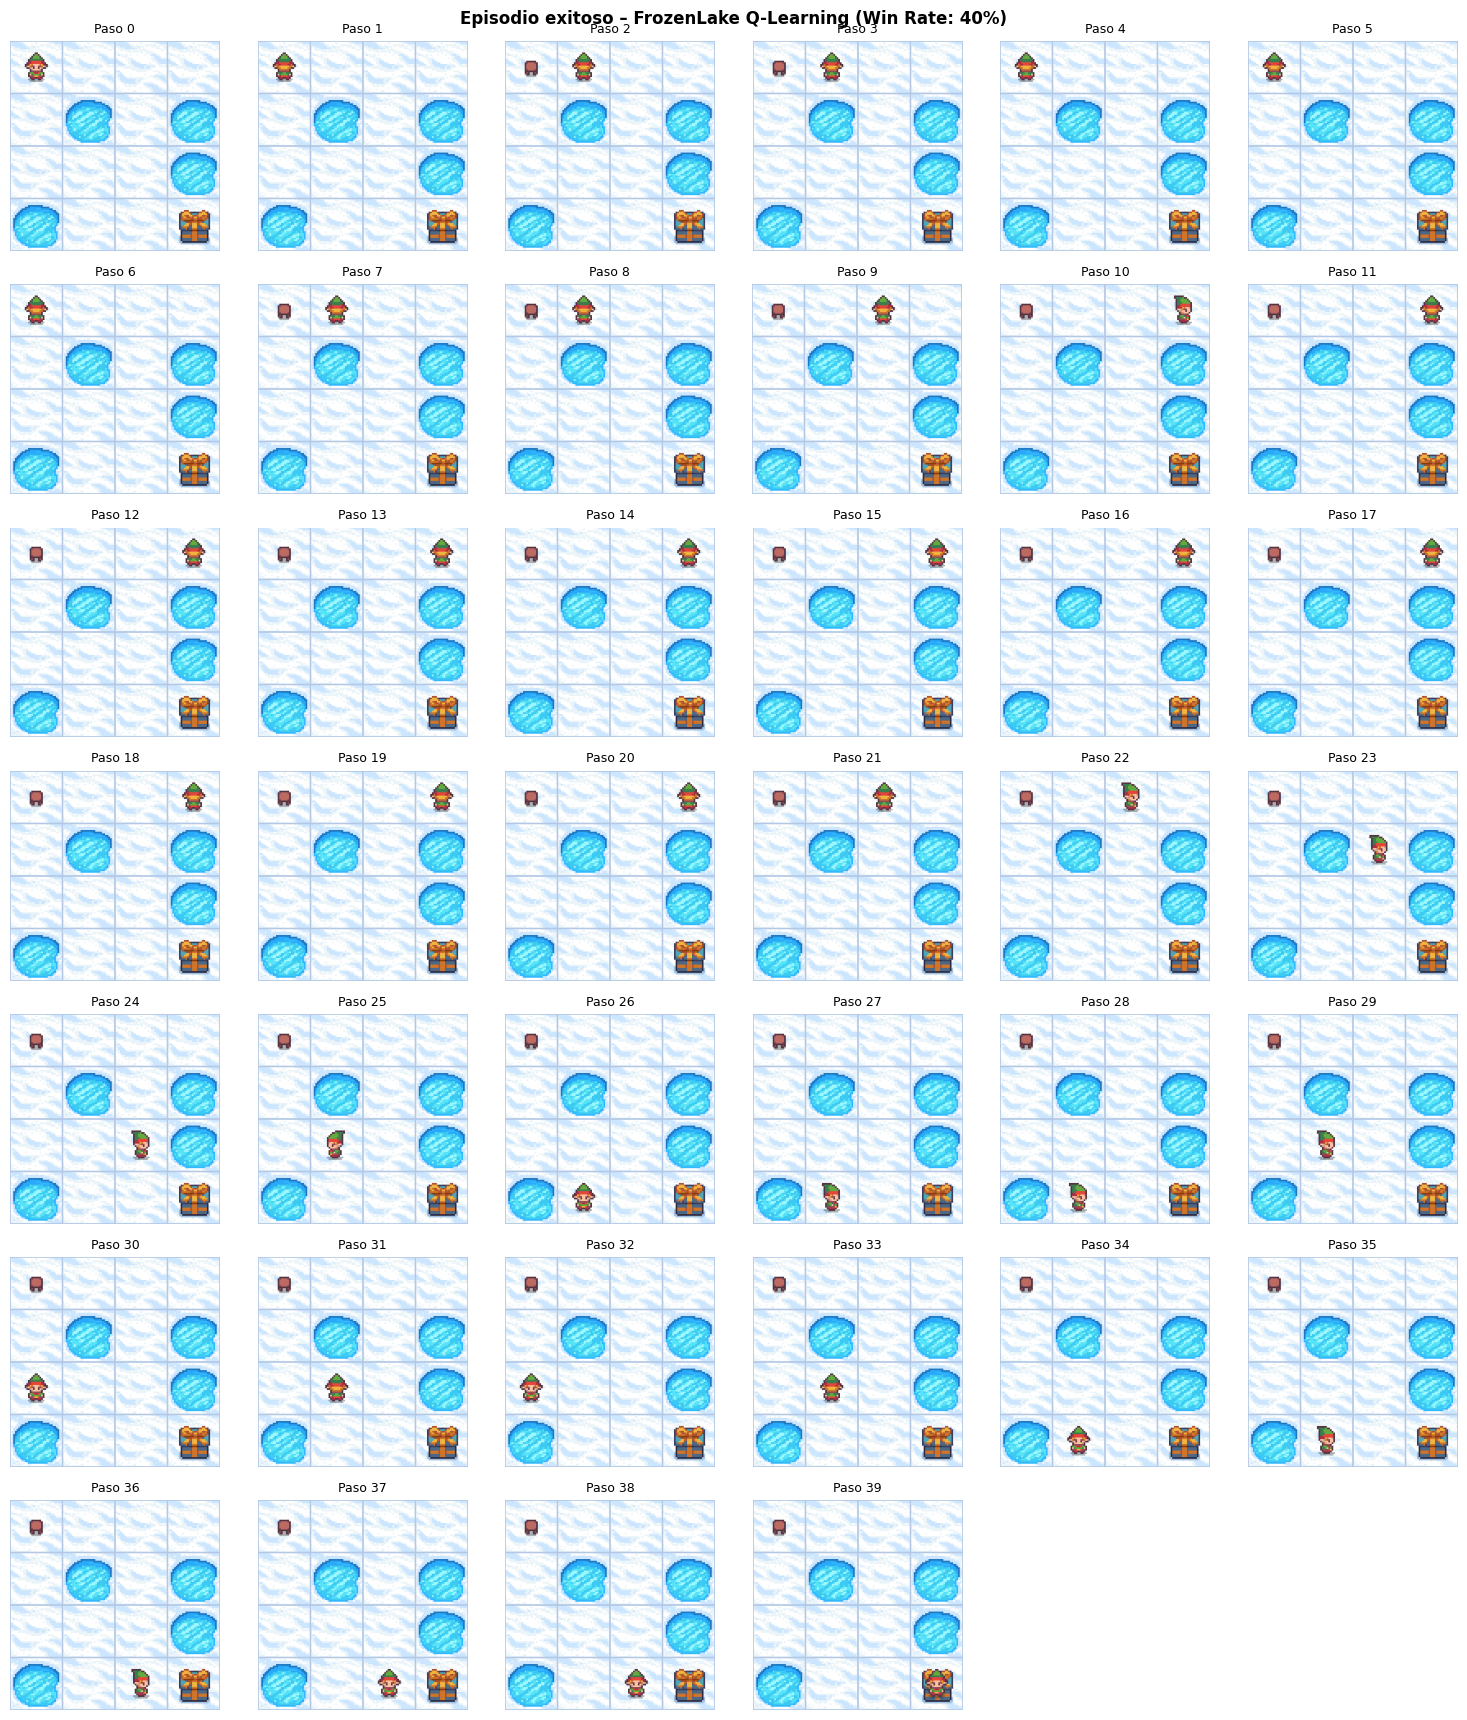

In [7]:

# ─── Task 2.3 – Evaluación sin exploración (ε = 0) ──────────────────────────

TEST_EPISODES = 10

# Entorno con render_mode para capturar frames del episodio exitoso
env_test = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")

wins           = 0
successful_frames = None   # Guardaremos los frames del primer episodio ganado

for ep in range(TEST_EPISODES):
    state, _ = env_test.reset()
    done      = False
    frames    = [env_test.render()]  # Frame estado inicial

    while not done:
        action              = np.argmax(Q[state, :])          # Puramente codicioso (ε = 0)
        state, reward, terminated, truncated, _ = env_test.step(action)
        done                = terminated or truncated
        frames.append(env_test.render())

    if reward == 1.0:          # Llegó a la meta
        wins += 1
        if successful_frames is None:
            successful_frames = frames  # Guardar primer episodio exitoso

win_rate = wins / TEST_EPISODES
print(f"Episodios de prueba : {TEST_EPISODES}")
print(f"Victorias           : {wins}")
print(f"Win Rate            : {win_rate:.0%}")

env_test.close()

# ─── Visualización de un episodio exitoso ────────────────────────────────────
if successful_frames:
    n_frames = len(successful_frames)
    cols     = min(n_frames, 6)
    rows     = (n_frames + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes      = np.array(axes).flatten()

    for i, frame in enumerate(successful_frames):
        axes[i].imshow(frame)
        axes[i].set_title(f"Paso {i}", fontsize=9)
        axes[i].axis("off")

    # Ocultar ejes sobrantes
    for j in range(n_frames, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"Episodio exitoso – FrozenLake Q-Learning (Win Rate: {win_rate:.0%})",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No se registró ningún episodio exitoso en los 10 intentos de prueba.")
